# SongNet: Real-time Music Classification
## Data Preprocessing and Mel-Spectrogram Generation

This notebook prepares the FMA-small dataset for the SongNet music
classification model.

Steps:
1. Load FMA metadata
2. Select FMA-small dataset
3. Verify genre distribution
4. Create clean audio paths
5. Split tracks into train, validation and test sets
6. Create genre labels
7. Load audio using Librosa
8. Generate Mel-spectrograms
9. Save processed metadata

In [73]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Executable:", sys.executable)

Python: 3.12.15 (main, Sep 30 2026, 22:04:19) [Clang 21.0.0 (clang-2100.3.34.2)]
Executable: /Users/gsretikkaprasad/Desktop/Music Data/songnet312/bin/python


In [74]:
PROJECT_ROOT = "/Users/gsretikkaprasad/Desktop/Music Data"

METADATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "fma_metadata",
    "tracks.csv"
)

AUDIO_ROOT = os.path.join(
    PROJECT_ROOT,
    "data",
    "fma_small"
)

PROCESSED_ROOT = os.path.join(
    PROJECT_ROOT,
    "processed"
)

os.makedirs(PROCESSED_ROOT, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Metadata exists:", os.path.isfile(METADATA_PATH))
print("Audio folder exists:", os.path.isdir(AUDIO_ROOT))
print("Processed folder:", PROCESSED_ROOT)

Project root: /Users/gsretikkaprasad/Desktop/Music Data
Metadata exists: True
Audio folder exists: True
Processed folder: /Users/gsretikkaprasad/Desktop/Music Data/processed


In [75]:
tracks = pd.read_csv(
    METADATA_PATH,
    header=[0, 1],
    index_col=0
)

print("Metadata shape:", tracks.shape)
print("Number of tracks:", len(tracks))

Metadata shape: (106574, 52)
Number of tracks: 106574


In [76]:
print("Available columns:")
print(tracks.columns.tolist())

Available columns:
[('album', 'comments'), ('album', 'date_created'), ('album', 'date_released'), ('album', 'engineer'), ('album', 'favorites'), ('album', 'id'), ('album', 'information'), ('album', 'listens'), ('album', 'producer'), ('album', 'tags'), ('album', 'title'), ('album', 'tracks'), ('album', 'type'), ('artist', 'active_year_begin'), ('artist', 'active_year_end'), ('artist', 'associated_labels'), ('artist', 'bio'), ('artist', 'comments'), ('artist', 'date_created'), ('artist', 'favorites'), ('artist', 'id'), ('artist', 'latitude'), ('artist', 'location'), ('artist', 'longitude'), ('artist', 'members'), ('artist', 'name'), ('artist', 'related_projects'), ('artist', 'tags'), ('artist', 'website'), ('artist', 'wikipedia_page'), ('set', 'split'), ('set', 'subset'), ('track', 'bit_rate'), ('track', 'comments'), ('track', 'composer'), ('track', 'date_created'), ('track', 'date_recorded'), ('track', 'duration'), ('track', 'favorites'), ('track', 'genre_top'), ('track', 'genres'), ('t

In [77]:
small = tracks[
    tracks[("set", "subset")] == "small"
].copy()

print("FMA-small tracks:", len(small))

FMA-small tracks: 8000


In [78]:
genre_counts = small[("track", "genre_top")].value_counts()

print(genre_counts)

(track, genre_top)
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64


In [79]:
clean_df = pd.DataFrame({
    "track_id": small.index.astype(int),
    "genre": small[("track", "genre_top")].values
})

print(clean_df.columns.tolist())
print("Shape:", clean_df.shape)

['track_id', 'genre']
Shape: (8000, 2)


In [80]:
clean_df = clean_df[
    clean_df["genre"].notna()
].copy()

print("Tracks after removing missing genres:", len(clean_df))

Tracks after removing missing genres: 8000


In [81]:
clean_df["filepath"] = clean_df["track_id"].apply(
    lambda x: os.path.join(
        AUDIO_ROOT,
        f"{int(x)//1000:03d}",
        f"{int(x):06d}.mp3"
    )
)

print(clean_df.columns.tolist())
print("Shape:", clean_df.shape)

['track_id', 'genre', 'filepath']
Shape: (8000, 3)


In [82]:
clean_df["exists"] = clean_df["filepath"].apply(
    os.path.isfile
)

print("Files found:", clean_df["exists"].sum())
print("Files missing:", (~clean_df["exists"]).sum())

Files found: 8000
Files missing: 0


In [83]:
sample_path = clean_df.iloc[0]["filepath"]

print("Sample path:")
print(sample_path)

print("\nType:")
print(type(sample_path))

print("\nExists:")
print(os.path.isfile(sample_path))

Sample path:
/Users/gsretikkaprasad/Desktop/Music Data/data/fma_small/000/000002.mp3

Type:
<class 'str'>

Exists:
True


In [84]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.30,
    stratify=clean_df["genre"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=1/3,
    stratify=temp_df["genre"],
    random_state=42
)

print("Training tracks:", len(train_df))
print("Validation tracks:", len(val_df))
print("Test tracks:", len(test_df))

Training tracks: 5600
Validation tracks: 1600
Test tracks: 800


In [85]:
print("TRAINING SET")
print(train_df["genre"].value_counts())

print("\nVALIDATION SET")
print(val_df["genre"].value_counts())

print("\nTEST SET")
print(test_df["genre"].value_counts())

TRAINING SET
genre
Folk             700
Electronic       700
Experimental     700
Pop              700
International    700
Hip-Hop          700
Instrumental     700
Rock             700
Name: count, dtype: int64

VALIDATION SET
genre
Instrumental     200
Rock             200
Experimental     200
Folk             200
Hip-Hop          200
Electronic       200
International    200
Pop              200
Name: count, dtype: int64

TEST SET
genre
Instrumental     100
Pop              100
International    100
Electronic       100
Folk             100
Hip-Hop          100
Experimental     100
Rock             100
Name: count, dtype: int64


In [86]:
GENRES = [
    "Electronic",
    "Experimental",
    "Folk",
    "Instrumental",
    "International",
    "Pop",
    "Hip-Hop",
    "Rock"
]

genre_to_label = {
    genre: i
    for i, genre in enumerate(GENRES)
}

label_to_genre = {
    i: genre
    for genre, i in genre_to_label.items()
}

print("Genre to label:")
print(genre_to_label)

Genre to label:
{'Electronic': 0, 'Experimental': 1, 'Folk': 2, 'Instrumental': 3, 'International': 4, 'Pop': 5, 'Hip-Hop': 6, 'Rock': 7}


In [87]:
train_df["label"] = train_df["genre"].map(genre_to_label)
val_df["label"] = val_df["genre"].map(genre_to_label)
test_df["label"] = test_df["genre"].map(genre_to_label)

print(train_df[["track_id", "genre", "label"]].head())

      track_id         genre  label
472      10992          Folk      2
4756    107910    Electronic      0
3925     87158    Electronic      0
4609    105712          Folk      2
6403    126605  Experimental      1


In [88]:
train_path = os.path.join(
    PROCESSED_ROOT,
    "train.csv"
)

val_path = os.path.join(
    PROCESSED_ROOT,
    "val.csv"
)

test_path = os.path.join(
    PROCESSED_ROOT,
    "test.csv"
)

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print("Saved:")
print(train_path)
print(val_path)
print(test_path)

Saved:
/Users/gsretikkaprasad/Desktop/Music Data/processed/train.csv
/Users/gsretikkaprasad/Desktop/Music Data/processed/val.csv
/Users/gsretikkaprasad/Desktop/Music Data/processed/test.csv


In [89]:
import librosa
import librosa.display

print("Librosa version:", librosa.__version__)

Librosa version: 1.0.0


In [90]:
sample_path = train_df.iloc[0]["filepath"]

audio, sr = librosa.load(
    sample_path,
    sr=22050,
    mono=True
)

print("Audio shape:", audio.shape)
print("Sample rate:", sr)
print("Duration:", len(audio) / sr, "seconds")

Audio shape: (661560,)
Sample rate: 22050
Duration: 30.002721088435376 seconds


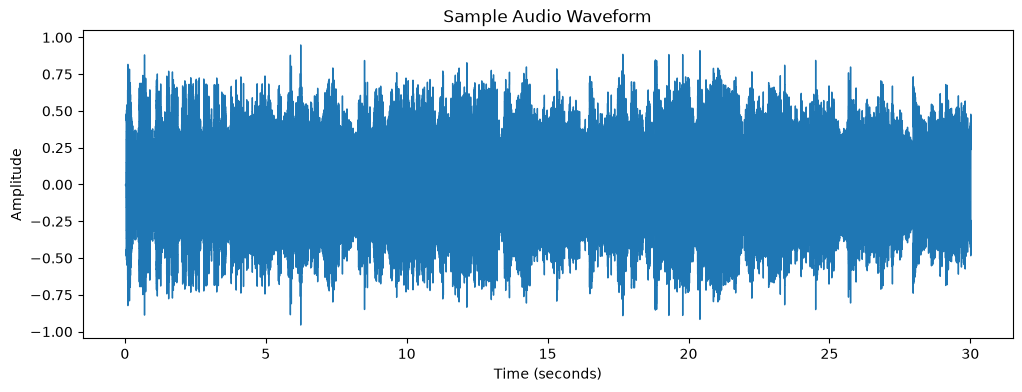

In [91]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Sample Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

In [92]:
mel_spectrogram = librosa.feature.melspectrogram(
    y=audio,
    sr=sr
)

mel_db = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max
)

print("Mel-spectrogram shape:", mel_db.shape)

Mel-spectrogram shape: (128, 1293)


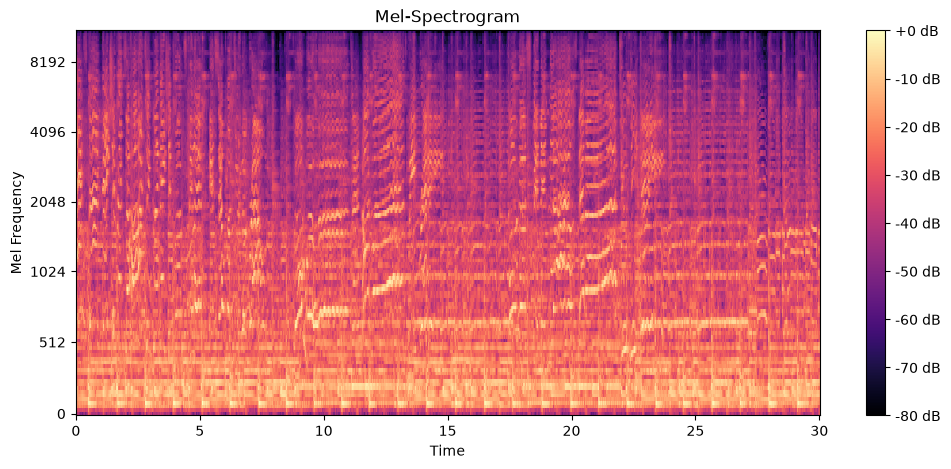

In [93]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel-Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.show()

In [94]:
print("Final dataset sizes")
print("--------------------")

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

Final dataset sizes
--------------------
Training: 5600
Validation: 1600
Test: 800

Total: 8000


In [95]:
print("Training columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(val_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

Training columns:
['track_id', 'genre', 'filepath', 'exists', 'label']

Validation columns:
['track_id', 'genre', 'filepath', 'exists', 'label']

Test columns:
['track_id', 'genre', 'filepath', 'exists', 'label']


In [96]:
print("SONGNET PREPROCESSING COMPLETE")
print("==============================")

print("Dataset: FMA-small")
print("Total tracks:", len(clean_df))
print("Number of genres:", len(GENRES))

print("\nGenre classes:")
for i, genre in enumerate(GENRES):
    print(i, "->", genre)

print("\nDataset split:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nAudio files:")
print("Found:", clean_df["exists"].sum())
print("Missing:", (~clean_df["exists"]).sum())

print("\nMel-spectrogram generation: Verified")

SONGNET PREPROCESSING COMPLETE
Dataset: FMA-small
Total tracks: 8000
Number of genres: 8

Genre classes:
0 -> Electronic
1 -> Experimental
2 -> Folk
3 -> Instrumental
4 -> International
5 -> Pop
6 -> Hip-Hop
7 -> Rock

Dataset split:
Train: 5600
Validation: 1600
Test: 800

Audio files:
Found: 8000
Missing: 0

Mel-spectrogram generation: Verified


In [97]:
# Cell 26: Create folders for model-ready Mel-spectrograms

MEL_ROOT = os.path.join(PROCESSED_ROOT, "mel_spectrograms")

TRAIN_MEL_ROOT = os.path.join(MEL_ROOT, "train")
VAL_MEL_ROOT = os.path.join(MEL_ROOT, "val")
TEST_MEL_ROOT = os.path.join(MEL_ROOT, "test")

os.makedirs(TRAIN_MEL_ROOT, exist_ok=True)
os.makedirs(VAL_MEL_ROOT, exist_ok=True)
os.makedirs(TEST_MEL_ROOT, exist_ok=True)

print("Mel-spectrogram folders created.")
print(MEL_ROOT)

Mel-spectrogram folders created.
/Users/gsretikkaprasad/Desktop/Music Data/processed/mel_spectrograms


In [98]:
# Cell 27: Mel-spectrogram configuration

SAMPLE_RATE = 22050
DURATION = 30

N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

print("Sample rate:", SAMPLE_RATE)
print("Duration:", DURATION, "seconds")
print("Number of Mel bins:", N_MELS)
print("FFT size:", N_FFT)
print("Hop length:", HOP_LENGTH)

Sample rate: 22050
Duration: 30 seconds
Number of Mel bins: 128
FFT size: 2048
Hop length: 512


In [99]:
# Cell 28: Mel-spectrogram generation function

def create_mel_spectrogram(filepath):
    audio, sr = librosa.load(
        filepath,
        sr=SAMPLE_RATE,
        mono=True,
        duration=DURATION
    )

    # Make every audio clip exactly 30 seconds
    target_length = SAMPLE_RATE * DURATION

    if len(audio) < target_length:
        audio = np.pad(
            audio,
            (0, target_length - len(audio))
        )
    else:
        audio = audio[:target_length]

    # Generate Mel-spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        power=2.0
    )

    # Convert power to decibels
    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return mel_db.astype(np.float32)

In [100]:
# Cell 29: Test Mel-spectrogram generation

test_path = train_df.iloc[0]["filepath"]

test_mel = create_mel_spectrogram(test_path)

print("Mel-spectrogram shape:", test_mel.shape)
print("Data type:", test_mel.dtype)
print("Minimum value:", test_mel.min())
print("Maximum value:", test_mel.max())

Mel-spectrogram shape: (128, 1292)
Data type: float32
Minimum value: -80.0
Maximum value: 0.0


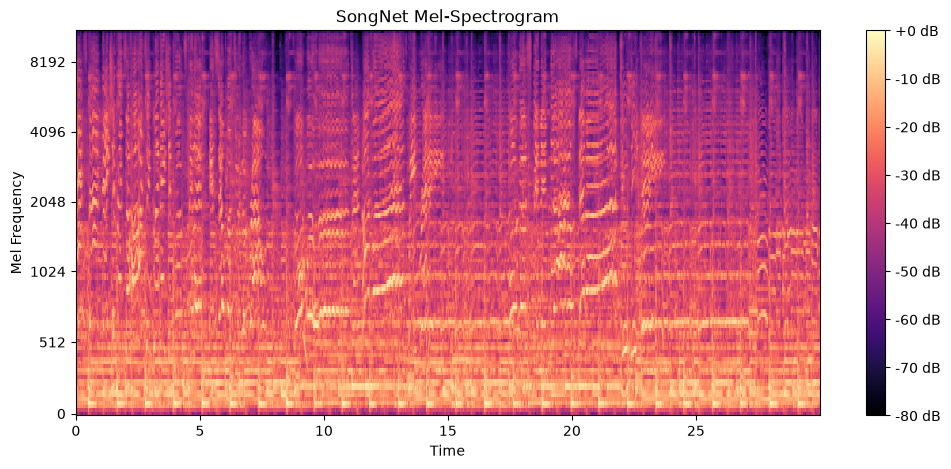

In [101]:
# Cell 30: Visual verification

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    test_mel,
    sr=SAMPLE_RATE,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("SongNet Mel-Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")
plt.show()

In [102]:
# Cell 31: Batch Mel-spectrogram generation

def process_split(df, output_folder, split_name):
    
    total = len(df)
    successful = 0
    failed = 0
    
    print(f"Processing {split_name}: {total} tracks")
    
    for i, (_, row) in enumerate(df.iterrows(), start=1):
        
        track_id = int(row["track_id"])
        filepath = row["filepath"]
        
        output_path = os.path.join(
            output_folder,
            f"{track_id:06d}.npy"
        )
        
        try:
            # Skip if already processed
            if os.path.exists(output_path):
                successful += 1
                continue
            
            mel = create_mel_spectrogram(filepath)
            
            np.save(output_path, mel)
            
            successful += 1
            
        except Exception as e:
            failed += 1
            print(f"\nError processing track {track_id}: {e}")
        
        if i % 100 == 0 or i == total:
            print(
                f"{split_name}: {i}/{total} processed | "
                f"Success: {successful} | Failed: {failed}"
            )
    
    print(f"\n{split_name} complete.")
    print("Successful:", successful)
    print("Failed:", failed)
    
    return successful, failed

In [103]:
# Cell 32: Generate training Mel-spectrograms

train_success, train_failed = process_split(
    train_df,
    TRAIN_MEL_ROOT,
    "Training"
)

Processing Training: 5600 tracks
Training: 100/5600 processed | Success: 100 | Failed: 0
Training: 200/5600 processed | Success: 200 | Failed: 0
Training: 300/5600 processed | Success: 300 | Failed: 0
Training: 400/5600 processed | Success: 400 | Failed: 0

Error processing track 108925: Error opening '/Users/gsretikkaprasad/Desktop/Music Data/data/fma_small/108/108925.mp3': File does not exist or is not a regular file (possibly a pipe?).


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


Training: 500/5600 processed | Success: 499 | Failed: 1
Training: 600/5600 processed | Success: 599 | Failed: 1
Training: 700/5600 processed | Success: 699 | Failed: 1
Training: 800/5600 processed | Success: 799 | Failed: 1
Training: 900/5600 processed | Success: 899 | Failed: 1
Training: 1000/5600 processed | Success: 999 | Failed: 1
Training: 1100/5600 processed | Success: 1099 | Failed: 1
Training: 1200/5600 processed | Success: 1199 | Failed: 1
Training: 1300/5600 processed | Success: 1299 | Failed: 1
Training: 1400/5600 processed | Success: 1399 | Failed: 1
Training: 1500/5600 processed | Success: 1499 | Failed: 1
Training: 1600/5600 processed | Success: 1599 | Failed: 1
Training: 1700/5600 processed | Success: 1699 | Failed: 1


[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
Note: Illegal Audio-MPEG-Header 0x00000000 at offset 63168.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).



Error processing track 98569: Unspecified internal error.
Training: 1800/5600 processed | Success: 1798 | Failed: 2
Training: 1900/5600 processed | Success: 1898 | Failed: 2
Training: 2000/5600 processed | Success: 1998 | Failed: 2
Training: 2100/5600 processed | Success: 2098 | Failed: 2
Training: 2200/5600 processed | Success: 2198 | Failed: 2
Training: 2300/5600 processed | Success: 2298 | Failed: 2
Training: 2400/5600 processed | Success: 2398 | Failed: 2
Training: 2500/5600 processed | Success: 2498 | Failed: 2


...

Training: 3800/5600 processed | Success: 3798 | Failed: 2
Training: 3900/5600 processed | Success: 3898 | Failed: 2


[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!


Training: 4000/5600 processed | Success: 3998 | Failed: 2
Training: 4100/5600 processed | Success: 4098 | Failed: 2
Training: 4200/5600 processed | Success: 4198 | Failed: 2
Training: 4300/5600 processed | Success: 4298 | Failed: 2
Training: 4400/5600 processed | Success: 4398 | Failed: 2
Training: 4500/5600 processed | Success: 4498 | Failed: 2
Training: 4600/5600 processed | Success: 4598 | Failed: 2
Training: 4700/5600 processed | Success: 4698 | Failed: 2


[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


Training: 4800/5600 processed | Success: 4798 | Failed: 2
Training: 4900/5600 processed | Success: 4898 | Failed: 2
Training: 5000/5600 processed | Success: 4998 | Failed: 2
Training: 5100/5600 processed | Success: 5098 | Failed: 2
Training: 5200/5600 processed | Success: 5198 | Failed: 2
Training: 5300/5600 processed | Success: 5298 | Failed: 2
Training: 5400/5600 processed | Success: 5398 | Failed: 2
Training: 5500/5600 processed | Success: 5498 | Failed: 2
Training: 5600/5600 processed | Success: 5598 | Failed: 2

Training complete.
Successful: 5598
Failed: 2


In [104]:
# Cell 33: Generate validation Mel-spectrograms

val_success, val_failed = process_split(
    val_df,
    VAL_MEL_ROOT,
    "Validation"
)

Processing Validation: 1600 tracks
Validation: 100/1600 processed | Success: 100 | Failed: 0
Validation: 200/1600 processed | Success: 200 | Failed: 0
Validation: 300/1600 processed | Success: 300 | Failed: 0
Validation: 400/1600 processed | Success: 400 | Failed: 0


Note: Illegal Audio-MPEG-Header 0x00000000 at offset 33361.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).



Error processing track 98565: Unspecified internal error.
Validation: 500/1600 processed | Success: 499 | Failed: 1
Validation: 600/1600 processed | Success: 599 | Failed: 1
Validation: 700/1600 processed | Success: 699 | Failed: 1


[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


Validation: 800/1600 processed | Success: 799 | Failed: 1
Validation: 900/1600 processed | Success: 899 | Failed: 1

Error processing track 133297: Error opening '/Users/gsretikkaprasad/Desktop/Music Data/data/fma_small/133/133297.mp3': File does not exist or is not a regular file (possibly a pipe?).


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


Validation: 1000/1600 processed | Success: 998 | Failed: 2
Validation: 1100/1600 processed | Success: 1098 | Failed: 2
Validation: 1200/1600 processed | Success: 1198 | Failed: 2
Validation: 1300/1600 processed | Success: 1298 | Failed: 2
Validation: 1400/1600 processed | Success: 1398 | Failed: 2
Validation: 1500/1600 processed | Success: 1498 | Failed: 2


Note: Illegal Audio-MPEG-Header 0x00000000 at offset 22401.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).



Error processing track 98567: Unspecified internal error.
Validation: 1600/1600 processed | Success: 1597 | Failed: 3

Validation complete.
Successful: 1597
Failed: 3


In [105]:
# Cell 34: Generate test Mel-spectrograms

test_success, test_failed = process_split(
    test_df,
    TEST_MEL_ROOT,
    "Test"
)

Processing Test: 800 tracks
Test: 100/800 processed | Success: 100 | Failed: 0
Test: 200/800 processed | Success: 200 | Failed: 0
Test: 300/800 processed | Success: 300 | Failed: 0

Error processing track 99134: Error opening '/Users/gsretikkaprasad/Desktop/Music Data/data/fma_small/099/099134.mp3': File does not exist or is not a regular file (possibly a pipe?).


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


Test: 400/800 processed | Success: 399 | Failed: 1
Test: 500/800 processed | Success: 499 | Failed: 1
Test: 600/800 processed | Success: 599 | Failed: 1
Test: 700/800 processed | Success: 699 | Failed: 1
Test: 800/800 processed | Success: 799 | Failed: 1

Test complete.
Successful: 799
Failed: 1


In [106]:
# Cell 35: Verify generated files

def count_npy_files(folder):
    return len([
        f for f in os.listdir(folder)
        if f.endswith(".npy")
    ])

train_mel_count = count_npy_files(TRAIN_MEL_ROOT)
val_mel_count = count_npy_files(VAL_MEL_ROOT)
test_mel_count = count_npy_files(TEST_MEL_ROOT)

print("Generated Mel-spectrograms")
print("-------------------------")
print("Training:", train_mel_count)
print("Validation:", val_mel_count)
print("Test:", test_mel_count)
print("Total:", train_mel_count + val_mel_count + test_mel_count)

Generated Mel-spectrograms
-------------------------
Training: 5598
Validation: 1597
Test: 799
Total: 7994


In [107]:
# Cell 36: Verify saved Mel-spectrogram

sample_mel_file = os.path.join(
    TRAIN_MEL_ROOT,
    f"{int(train_df.iloc[0]['track_id']):06d}.npy"
)

loaded_mel = np.load(sample_mel_file)

print("File:", sample_mel_file)
print("Shape:", loaded_mel.shape)
print("Data type:", loaded_mel.dtype)
print("File exists:", os.path.isfile(sample_mel_file))

File: /Users/gsretikkaprasad/Desktop/Music Data/processed/mel_spectrograms/train/010992.npy
Shape: (128, 1292)
Data type: float32
File exists: True


In [108]:
# Cell 37: Verify track-to-Mel mapping

train_df["mel_path"] = train_df["track_id"].apply(
    lambda x: os.path.join(
        TRAIN_MEL_ROOT,
        f"{int(x):06d}.npy"
    )
)

val_df["mel_path"] = val_df["track_id"].apply(
    lambda x: os.path.join(
        VAL_MEL_ROOT,
        f"{int(x):06d}.npy"
    )
)

test_df["mel_path"] = test_df["track_id"].apply(
    lambda x: os.path.join(
        TEST_MEL_ROOT,
        f"{int(x):06d}.npy"
    )
)

print("Training missing Mel files:",
      (~train_df["mel_path"].apply(os.path.isfile)).sum())

print("Validation missing Mel files:",
      (~val_df["mel_path"].apply(os.path.isfile)).sum())

print("Test missing Mel files:",
      (~test_df["mel_path"].apply(os.path.isfile)).sum())

Training missing Mel files: 2
Validation missing Mel files: 3
Test missing Mel files: 1


In [109]:
# Cell 38: Save final model-ready metadata

train_model_ready_path = os.path.join(
    PROCESSED_ROOT,
    "train_model_ready.csv"
)

val_model_ready_path = os.path.join(
    PROCESSED_ROOT,
    "val_model_ready.csv"
)

test_model_ready_path = os.path.join(
    PROCESSED_ROOT,
    "test_model_ready.csv"
)

train_df.to_csv(train_model_ready_path, index=False)
val_df.to_csv(val_model_ready_path, index=False)
test_df.to_csv(test_model_ready_path, index=False)

print("Model-ready CSV files saved.")
print(train_model_ready_path)
print(val_model_ready_path)
print(test_model_ready_path)

Model-ready CSV files saved.
/Users/gsretikkaprasad/Desktop/Music Data/processed/train_model_ready.csv
/Users/gsretikkaprasad/Desktop/Music Data/processed/val_model_ready.csv
/Users/gsretikkaprasad/Desktop/Music Data/processed/test_model_ready.csv


In [110]:
# Cell 39: Final Member 1 verification

print("=" * 50)
print("SONGNET MEMBER 1 PREPROCESSING COMPLETE")
print("=" * 50)

print("\nDataset")
print("-------")
print("Total tracks:", len(clean_df))
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nMel-spectrograms")
print("----------------")
print("Training:", train_mel_count)
print("Validation:", val_mel_count)
print("Test:", test_mel_count)
print("Total:", train_mel_count + val_mel_count + test_mel_count)

print("\nMel configuration")
print("-----------------")
print("Sample rate:", SAMPLE_RATE)
print("Duration:", DURATION)
print("Mel bins:", N_MELS)
print("FFT:", N_FFT)
print("Hop length:", HOP_LENGTH)

print("\nMember 1 output")
print("----------------")
print("FMA-small metadata")
print("Train/validation/test split")
print("Audio path mapping")
print("Mel-spectrogram generation")
print("Model-ready CSV files")

print("\nReady for Member 2: C-RNN implementation")

SONGNET MEMBER 1 PREPROCESSING COMPLETE

Dataset
-------
Total tracks: 8000
Training: 5600
Validation: 1600
Test: 800

Mel-spectrograms
----------------
Training: 5598
Validation: 1597
Test: 799
Total: 7994

Mel configuration
-----------------
Sample rate: 22050
Duration: 30
Mel bins: 128
FFT: 2048
Hop length: 512

Member 1 output
----------------
FMA-small metadata
Train/validation/test split
Audio path mapping
Mel-spectrogram generation
Model-ready CSV files

Ready for Member 2: C-RNN implementation
